# Programming exercise 9: The AKLT model and matrix product states

Due on Monday, 22.06.2026, 20h

In [1]:
# load standard libraries

import scipy.sparse.linalg as spla
import numpy as np
import numpy.linalg as npla
import matplotlib.pyplot as plt

import Comp_Quant_Dynam as cqd

### Exercise 1: Solving the AKLT model with exact diagonalization

We want to study a quantum many-body model for spins known as the AKLT model which was introduced in the 80's to explore the so-called Haldane conjecture (see https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.59.799). It has a couple of remarkable features that will allow us to use it as a playground for testing the basic ideas surrounding matrix product states. As additional practice on how to build general spin models and exact diagonalization, we will start by solving it here by numerical means and then compare the result to some theoretical predictions. You can use some of the code from the last exercise as a basis but make sure to modify the operators as now we are working with spin 1!  

As mentioned, this is a spin 1 model and it lives on a one-dimensional chain with periodic boundary conditions (using the correct boundary condition is critical here). The Hamiltonian is given by

$$
H=J\sum_{i=0}^{N-1}\left(\frac{1}{3} +\frac{1}{2}S^{(i)}\cdot S^{(i+1)}+\frac{1}{6}(S^{(i)}\cdot S^{(i+1)})^2\right)
$$
Remember that, due to the periodic boundary conditions, the $N$ th spin is identified with the $0$ th spin. $S^{(i)}$ denotes the vector of spin operators $(S_x^{(i)}, S_y^{(i)}, S_z^{(i)})$. It might be convenient to use the following representation for their products:
$$
S^{(i)}\cdot S^{(i+1)} = S_z^{(i)} S_z^{(i+1)}+\frac{1}{2}\left(S_+^{(i)}S_-^{(i+1)}+S_-^{(i)}S_+^{(i+1)}\right)
$$
where the relevant spin 1 spin operators are $S_z=-|-1\rangle\langle-1| + |+1\rangle\langle+1|$, $S_+=\sqrt{2}(|+1\rangle\langle 0| + |0\rangle\langle -1|)$ and $S_- = S_+^\dagger$ (with $|s\rangle$ denoting the basis states in the $S_z$ eigenbasis).

Build the Hamiltonian in the standard product basis ($J$ is just a global energy scale and can be set to 1).

First you can test your implementation by calculating the ground state energy and making sure it is zero as this is the theoretical prediction. Another test is the magnetization in $z$ direction which should also be zero.

Once you are confident that your code is working you should compute the energy gap between ground and first excited state for a couple of system sizes $N$ and see how it behaves. Is the system gapped? This question is directly related to the Haldane conjecture.

Finally, compute the correlation function $\langle S_z^{(i)}S_z^{(i+r)} \rangle$ as a function of $r$ and compare to the theoretical result:
$$
\langle S_z^{(i)}S_z^{(i+r)}\rangle \propto \left(\frac{-1}{3}\right)^r
$$

It probably won't look so good as the exact diagonalization is not the best tool to study this but you should get some agreement.


Optional: Investigate what happens for open boundary conditions and see if there is any qualitative difference.

In [2]:
""" local operators """

sp_sprs, sm_sprs, sz_sprs = cqd.operators.build_single_spin_1_ops_sparse()

In [3]:
N = 4
local_dims = [3] * N
H_mat = cqd.hamiltonians.build_H_AKLT(N)
evals, evecs = spla.eigsh(H_mat, k=10, which = 'SA')
print("Eigenvalues: ", evals)
print()
# magnetization
sz_list = np.zeros((N,), dtype='complex')
for i in range(N):
    sz_i = cqd.operators.n_party_op_sparse(local_dims, i, sz_sprs)
    sz_list[i] = cqd.utility.expectation_value(evecs[:,0], sz_i)
    
print("Magnetization: ", sz_list)

# -> both ground state energy and magnetzation are zero indeed, the excited states are degenerate

Eigenvalues:  [-1.27198566e-16  3.33333333e-01  3.33333333e-01  3.33333333e-01
  7.36237384e-01  7.36237384e-01  7.36237384e-01  7.36237384e-01
  7.36237384e-01  7.84749563e-01]

Magnetization:  [-1.66533454e-16+0.j  1.94289029e-16+0.j -1.04083409e-16+0.j
  1.04083409e-16+0.j]


In [4]:
# loop N to see that the gap won't close
N_vec = range(2, 13)
k = 2
all_evals = np.zeros((len(N_vec), k))
for i, N in enumerate(N_vec):
    print(N, end=' ')
    H_mat = cqd.hamiltonians.build_H_AKLT(N)
    evals, evecs = spla.eigsh(H_mat, k=2, which='SA')
    all_evals[i] = evals

2 3 4 5 6 7 8 9 10 11 12 

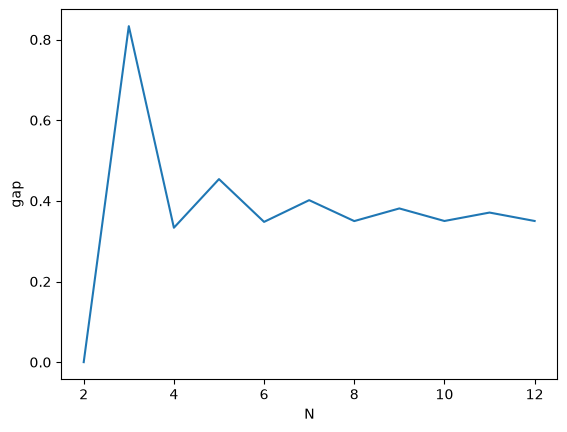

In [5]:
plt.plot(N_vec, all_evals[:, 1] - all_evals[:, 0])
plt.xlabel("N")
plt.ylabel("gap")
plt.show()

# -> seems to converge to ~3.6

In [6]:
# zz-correlations
N = 10
local_dims = [3] * N
H_mat = cqd.hamiltonians.build_H_AKLT(N)
evals, evecs = spla.eigsh(H_mat, k=2, which='SA')
gs = evecs[:,0]
szsz_list= np.zeros((N - 1,), dtype='complex')
# correlation between spin 0 and r
for i in range(N - 1):
    szsz = cqd.operators.n_party_op_sparse(local_dims, [0, i+1], [sz_sprs, sz_sprs])
    szsz_list[i] = cqd.utility.expectation_value(gs, szsz)
    
# check translation invariance: correlation between spin 1 and r + 1
szsz_list2= np.zeros((N - 1,), dtype='complex')
for i in range(N-1):
    szsz = cqd.operators.n_party_op_sparse(local_dims, [1, np.mod(i + 2, N)], [sz_sprs, sz_sprs])
    szsz_list2[i] = cqd.utility.expectation_value(gs, szsz)


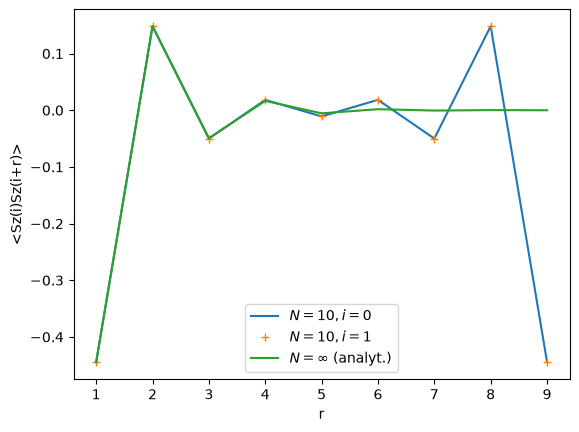

In [7]:
rvec = np.arange(1,N)
plt.plot(rvec, szsz_list.real)
plt.plot(rvec, szsz_list2.real, '+')
plt.plot(rvec, 4 / 3 * (-1 / 3) ** rvec)
plt.xlabel("r")
plt.ylabel("<Sz(i)Sz(i+r)>")
plt.legend(["$N=10, i=0$", "$N=10, i=1$", "$N=\\infty$ (analyt.)"])
plt.show()

# -> agreement with analytical formula is still rather poor for N=10, finite size effects are obvious

In [8]:
# open boundary conditions

# loop N to see how the gap behaves
N_vec = range(2, 13)
k = 2
all_evals_obc = np.zeros((len(N_vec),k))
for i, N in enumerate(N_vec):
    print(N, end=' ')
    H_mat = cqd.hamiltonians.build_H_AKLT(N, open_bc=True)
    evals, evecs = spla.eigsh(H_mat, k=k, which='SA')
    all_evals_obc[i] = evals

2 3 4 5 6 7 8 9 10 11 12 

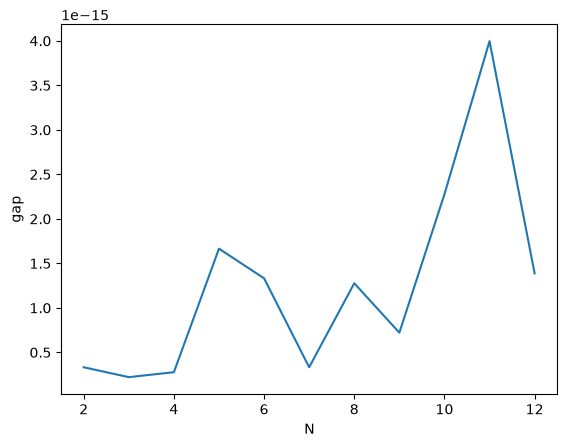

In [9]:
plt.plot(N_vec, all_evals_obc[:, 1] - all_evals_obc[:, 0])
plt.xlabel("N")
plt.ylabel("gap")
plt.show()

# -> ground state is degenerate!

In [10]:
# magnetization and correlations
N = 10
local_dims = [3] * N
Hmat = cqd.hamiltonians.build_H_AKLT(N, open_bc=True)
evals, evecs = spla.eigsh(Hmat, k=2, which='SA')
gs = evecs[:,0]

sz_list = np.zeros((N,), dtype='complex')
for i in range(N):
    szi = cqd.operators.n_party_op_sparse(local_dims, i, sz_sprs)
    sz_list[i] = cqd.utility.expectation_value(gs, szi)
    
szsz_list = np.zeros((N-1,),dtype='complex')
# correlation between spin 0 and r
for i in range(N-1):
    szsz = cqd.operators.n_party_op_sparse(local_dims, [0, i+1], [sz_sprs, sz_sprs])
    szsz_list[i] = cqd.utility.expectation_value(gs, szsz)
    
# check translation invariance: correlation between spin 1 and r
szsz_list2 = np.zeros((N-1,),dtype='complex')
for i in range(N-1):
    szsz = cqd.operators.n_party_op_sparse(local_dims, [1, np.mod(i + 2,N)], [sz_sprs, sz_sprs])
    szsz_list2[i] = cqd.utility.expectation_value(gs, szsz)

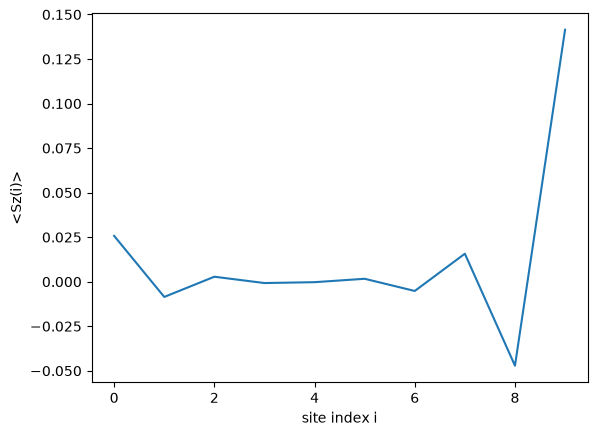

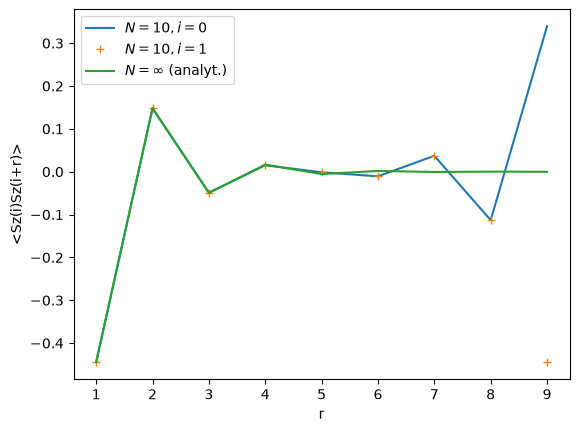

In [11]:
plt.plot(np.arange(N),sz_list.real)
plt.xlabel("site index i")
plt.ylabel("<Sz(i)>")
plt.show()

rvec = np.arange(1,N)
plt.plot(rvec, szsz_list.real)
plt.plot(rvec, szsz_list2.real, '+')
plt.plot(rvec, 4 / 3 * (-1 / 3) ** rvec)
plt.xlabel("r")
plt.ylabel("<Sz(i)Sz(i+r)>")
plt.legend(["$N=10, i=0$", "$N=10, i=1$", "$N=\\infty$ (analyt.)"])
plt.show()

# -> magnetization is non-zero
# -> correlations look similar as before.
#    I expected them to just oscillate and decay, but they seem to be quite strong between the first and the last spin??

### Optional Exercise 2: Entanglement in the phase diagram

Now we are going to look at entanglement in the AKLT model but to make things more interesting we add a parameter $\theta$ to the Hamiltonian:
$$
H=J\sum_{i=0}^{N-1}\left(\frac{\cos(\theta)}{3 \cos(\theta_{0})} +\frac{\cos(\theta)}{2 \cos(\theta_{0})}S^{(i)}\cdot S^{(i+1)}+\frac{\sin(\theta)}{2 \cos(\theta_{0})}(S^{(i)}\cdot S^{(i+1)})^2\right)
$$
where $\theta_0 = \arctan(1/3)$ is a special angle that allows us to go back to the original Hamiltonian with $\theta=\theta_0$.


Study what happens to the gap of the system as you change $\theta$, moving away from $\theta_0$, and interpret your results. After this you should look at the entanglement of the ground state for different $\theta$ taking into account your conclusions about the gap. What happens to the (half chain) entanglement entropy and the Schmidt rank as $\theta$ changes?

Hint: An elegant way to compute partial traces is to use the function reshape() as it allows you to rewrite your state as a matrix in the way required for a Schmidt decomposition. After that all you need to do to get the entanglement spectrum is perform a svd (also available in the usual places) and look at the singular values.

In [ ]:
# this takes a while to run (approx. 1 min on my laptop)

N = 10
theta0 = np.arctan(1 / 3)
theta_vec = np.arange(0, np.pi / 2, 0.1 * theta0)
k = 5
local_dim = 3
local_dims = [local_dim] * N
dimA = dimB = int(local_dim ** (N / 2))
all_evals = np.zeros((len(theta_vec), k))
all_schmidt = np.zeros((len(theta_vec), min(dimA, dimB)))
all_SvN = np.zeros((len(theta_vec),))
for i, theta in enumerate(theta_vec):
    print(f"{(i) / len(theta_vec) * 100:.2f}%", end=' ')
    Hmat = cqd.hamiltonians.build_H_AKLT(N, theta = theta)
    evals, evecs = spla.eigsh(Hmat, k=k, which='SA')
    all_evals[i] = evals
    # calculate Schmidt coefficientes for half/half splitting
    gs = evecs[:,0]
    gs_mat = gs.reshape(dimA, dimB)
    all_schmidt[i] = npla.svd(gs_mat,compute_uv=False)
    # entanglement entropy
    evals_red = all_schmidt[i] ** 2
    all_SvN[i] = cqd.utility.entanglement_entropy_from_evals(evals_red)
print("100%")
    

0.00% 2.04% 4.08% 6.12% 8.16% 10.20% 12.24% 14.29% 16.33% 18.37% 20.41% 22.45% 24.49% 26.53% 28.57% 30.61% 32.65% 34.69% 36.73% 38.78% 40.82% 42.86% 44.90% 46.94% 48.98% 51.02% 53.06% 55.10% 57.14% 59.18% 61.22% 63.27% 65.31% 67.35% 69.39% 71.43% 73.47% 75.51% 77.55% 79.59% 81.63% 83.67% 85.71% 87.76% 89.80% 91.84% 93.88% 95.92% 97.96% 

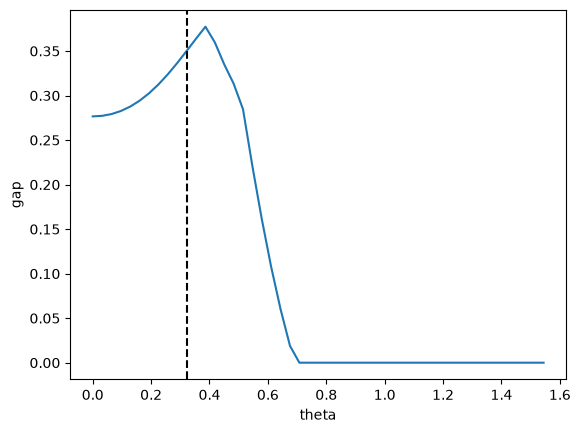

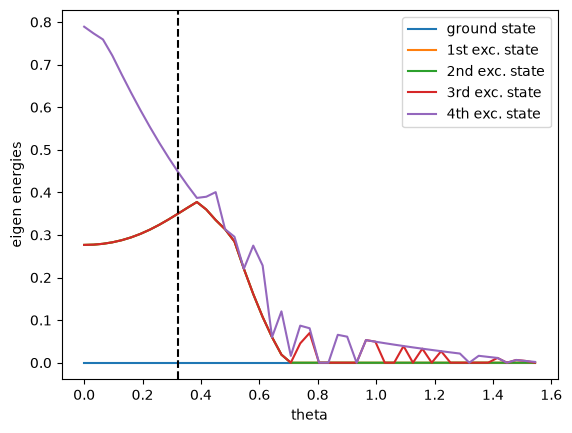

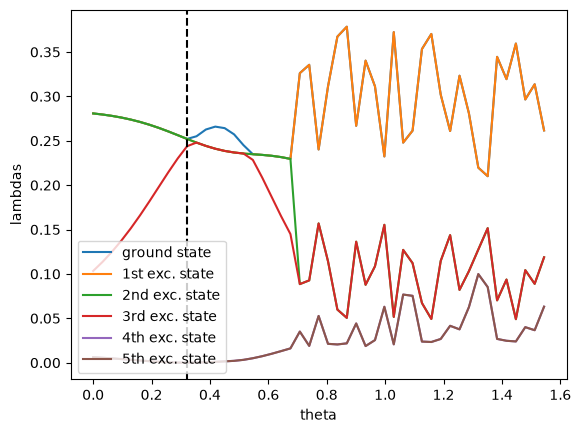

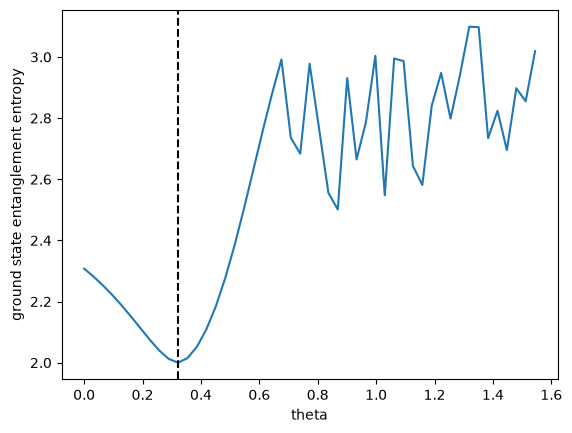

In [ ]:
legend_strings = ["ground state", "1st exc. state", "2nd exc. state", "3rd exc. state", "4th exc. state" , "5th exc. state" ]

plt.plot(theta_vec, all_evals[:,1] - all_evals[:,0])
plt.axvline(x=theta0, linestyle='--', color='k')
plt.xlabel("theta")
plt.ylabel("gap")
plt.show()

imax_plot = 5
for i in range(imax_plot):
    plt.plot(theta_vec, all_evals[:, i] - all_evals[:, 0])

plt.axvline(x=theta0,linestyle='--',color='k')
plt.xlabel("theta")
plt.ylabel("eigen energies")
plt.legend(legend_strings[:imax_plot])
plt.show()

kmax_plot = 6
for i in range(kmax_plot):
    plt.plot(theta_vec, all_schmidt[:, i] ** 2)

plt.axvline(x=theta0, linestyle='--',color='k')
plt.xlabel("theta")
plt.ylabel("lambdas")
plt.legend(legend_strings[:kmax_plot], loc='lower left')
plt.show()

plt.plot(theta_vec, all_SvN)
plt.axvline(x=theta0, linestyle='--', color='k')
plt.xlabel("theta")
plt.ylabel("ground state entanglement entropy")
plt.show()

# -> The gap suddenly closes at some value of theta!
# -> There also seem to be some numerical instabilities...
# -> SvN of half system is minimal at the AKLT point, in the gappless phase becomes large

In [ ]:
# calculate entanglement spectrum for the original AKLT model
N = 10
local_dim = 3
H_mat = cqd.hamiltonians.build_H_AKLT(N)
e,v = spla.eigsh(H_mat, k=2, which='SA')
gs = v[:,0]
dimA = dimB = int(local_dim ** (N / 2))
gsMat = gs.reshape(dimA, dimB)
s = npla.svd(gsMat, compute_uv=False)
print("Entanglement spectrum :", s[:5])

# -> For the AKLT (theta=theta0), the entanglement dimension is 4 as expected 
#    (for periodic boundaries we are cutting 2 bonds each with dimension 2.)

[5.02044860e-01 5.02044860e-01 5.02044860e-01 4.93814616e-01
 3.13750846e-16]


### Exercise 3: MPS description

Finally we will use the MPS machinery and explain why we chose to study the AKLT model (besides the fact that it is a pretty cool model :)). Usually for any given Hamiltonian it is necessary to apply a (complicated) procedure to find a good MPS approximation for the ground states (see lecture 10 notes). The AKLT ground states is special in that it admits an exact MPS description so we can directly apply the tensor network techniques to it! The representation only requires bond dimension 2 and is given by the following 2x2 matrices:
$$
A_{+1}=\sqrt{\frac{2}{3}} \sigma_+\\
A_{0}=-\sqrt{\frac{1}{3}} \sigma_z\\
A_{-1}=-\sqrt{\frac{2}{3}} \sigma_-\\
$$

Show that this really gives the ground state by comparing it to the states you got from exact diagonalization. To do so you should compute the ground state in the basis used in exercise 1 from the given MPS (i.e. compute the coefficients $c_{s_0\dots s_{N-1}}=Tr(\dots)$ from given A-Tensors)
$$
|\psi_{\text{mps}}\rangle = \sum_{s_0\dots s_{N-1}} Tr(A_{s_0}A_{s_1}\dots A_{s_{N-1}})|s_0 s_1 \dots s_{N-1}\rangle
$$
and compute the overlap $\langle\psi_{\text{ed}}|\psi_{\text{mps}}\rangle$ with the exact diagonalization ground state. Of course, this is not very smart as we are using our efficient MPS representation to reconstruct the inefficient ED representation, but it is a good sanity check nonetheless. 

You might notice a small deviation in the overlap. This comes from the fact that the MPS state is not normalized and you can see this by computing the norm directly from the matrices:
$$
\langle\psi_{\text{mps}}|\psi_{\text{mps}}\rangle = Tr(E^n)
$$
where
$$
E = \sum_s A_s\otimes A_s^*\\
$$
is the local matrix corresponding to the identity operator. Make sure you understand where this formula comes from, using the diagrammatic representation. Show that the deviation from 1 is small and vanishes exponentially for large systems.

Now, for the real benefits of the MPS, let's compute the correlation function $\langle S_z^{(i)}S_z^{(i+r)}\rangle$ from exercise 1. This can be done for very large systems by simply replacing two E matrices in the expression for the norm with
$$
E_z = \sum_{s,s'}\langle s|S_z|s'\rangle A_s\otimes A_{s'}^*
$$
which is the local matrix for $S_z$. Think about the correct position where the $E_z$ should go and use this to compute the correlation function. Compare the results to the theoretical prediction mentioned in the first exercise.

Optional: The AKLT model has a hidden order that manifests itself through a string operator:
$$
\langle S_z^{(i)}\,\exp\left[\sum_{i<k<j}i \pi S_z^{(k)}\right] \,  S_z^{(j)}\rangle
$$
Compute this order parameter and show that it maintains a constant value for $|i-j|>2$.

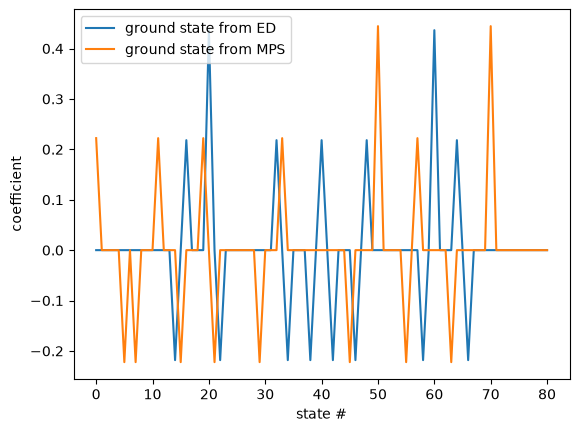

Overlap: 7.663938300286111e-19
MPS norm: 1.037037037037037
ED norm: 1.0000000000000007
Normalized overlap: 7.52583801054265e-19


In [ ]:
sig_x = cqd.operators.sigma_x_sparse()
sig_y = cqd.operators.sigma_y_sparse()
sig_z = cqd.operators.sigma_z_sparse()

sig_p = (sig_x + 1j * sig_y).real / 2
sig_m = sig_p.T

a_tensor_arr = np.array([np.sqrt(2 / 3) * sig_p, -np.sqrt(1 / 3) * sig_z, -np.sqrt(2 / 3) * sig_m])

N = 4
local_dim = 3
global_dim = local_dim ** N
Hmat = cqd.hamiltonians.build_H_AKLT(N)
evals, evecs = spla.eigsh(Hmat, k=2, which='SA')
gs = evecs[:,0]
plt.plot(gs, label = "ground state from ED")

mps_coeffs = np.zeros((global_dim,))
for ind in range(global_dim):
    mps_coeffs[ind] = cqd.operators.get_coeff_MPS(cqd.utility.n_party_idx2state(ind, local_dim, N), a_tensor_arr)

plt.plot(mps_coeffs, label = "ground state from MPS")
plt.xlabel('state #')
plt.ylabel('coefficient')
plt.legend()
plt.show()

print("Overlap:", np.dot(gs, mps_coeffs))
print("MPS norm:", np.dot(mps_coeffs, mps_coeffs))
print("ED norm:", np.vdot(gs, gs))

"""
-> agrees except sometimes for an overall sign 
(phase is anyway undetermined and we don't know which sign the diagonalization routine will return) 
and the mentioned norm difference
"""

# normalize the mps before calculating the fidelity
mps_coeffs_normalized = mps_coeffs / npla.norm(mps_coeffs)

print("Normalized overlap:", np.dot(gs, mps_coeffs_normalized))


In [ ]:
cqd.utility.n_party_idx2state(17, local_dim, N)

array([1, 1, 1, 1], dtype=int32)

In [ ]:
cqd.utility.n_party_idx2state_old(17, local_dim, N)

array([ 1,  0, -1, -1], dtype=int32)

E =  [[ 0.33333333  0.          0.          0.66666667]
 [ 0.         -0.33333333  0.          0.        ]
 [ 0.          0.         -0.33333333  0.        ]
 [ 0.66666667  0.          0.          0.33333333]]
tr(E^N) =  0.999999999999996


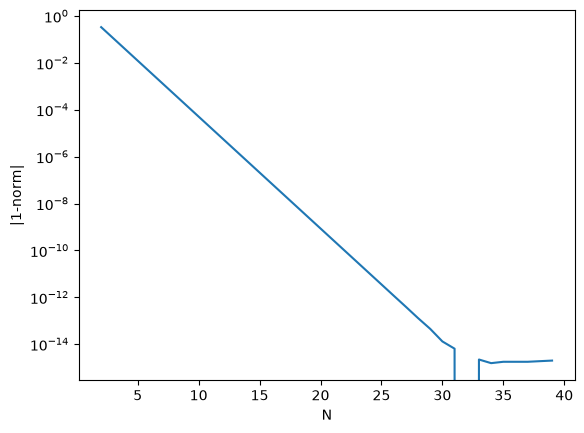

In [ ]:
# calculate the norm efficiently
E_mat = cqd.operators.build_E_mat_MPS(a_tensor_arr).real
print("E = ", E_mat)

N = 80
print("tr(E^N) = ", np.trace(npla.matrix_power(E_mat,N)))

# -> for large N the norm converges to 1. The results is consistent with the norm of the coefficient vector from above
# matrix power is fast enough, so I don't diagonalize

N_vec = np.arange(2, 40)
norm_list = np.zeros(N_vec.shape)
for i in range(len(N_vec)):
    norm_list[i] = np.trace(npla.matrix_power(E_mat, N_vec[i]))
    
plt.plot(N_vec,np.abs(1 - norm_list))
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('|1-norm|')
plt.show()

# -> around N=35 the deviation of the norm becomes smaller than double precision

In [ ]:
# magnetization and correlations
N = 10
Hmat = cqd.hamiltonians.build_H_AKLT(N)
e,v = spla.eigsh(Hmat, k=2, which='SA')
gs = v[:,0]
szsz_list = np.zeros((N - 1, 1), dtype='complex')

# correlation between spin 0 and r
for i in range(N - 1):
    szsz = cqd.operators.n_party_op_sparse(local_dims, [0, i + 1], [sz_sprs, sz_sprs])
    szsz_list[i] = cqd.utility.expectation_value(gs, szsz)

Ez_mat = cqd.operators.build_E_mat_MPS(a_tensor_arr, sz_sprs).real
    
# same for mps
szsz_list_mps= np.zeros((N - 1,))
for i in range(N - 1):
    szsz_list_mps[i] = cqd.operators.corr_func_MPS(N, E_mat, np.array([0, i + 1]), np.array([Ez_mat, Ez_mat]))

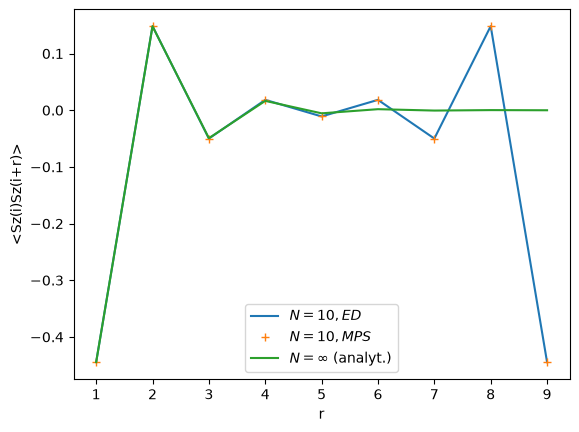

In [ ]:
rvec = np.arange(1, N)
plt.plot(rvec, szsz_list.real)
plt.plot(rvec, szsz_list_mps, '+')
plt.plot(rvec, 4 / 3 * (-1 / 3) ** rvec)
plt.xlabel("r")
plt.ylabel("<Sz(i)Sz(i+r)>")
plt.legend(["$N=10, ED$", "$N=10, MPS$", "$N=\\infty$ (analyt.)"])
plt.show()

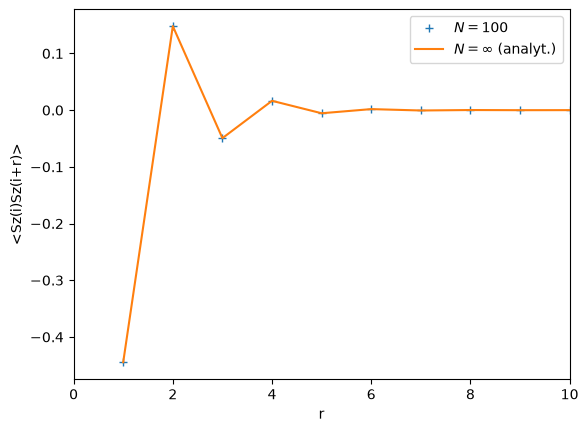

In [ ]:
# show the power of the MPS: large system
N = 100
    
# same for mps
szsz_list_mps = np.zeros((N - 1,))
for i in range(N - 1):
    szsz_list_mps[i] =  cqd.operators.corr_func_MPS(N, E_mat, np.array([0, i + 1]), np.array([Ez_mat, Ez_mat]))

rvec = np.arange(1, N)
plt.plot(rvec, szsz_list_mps, '+')
plt.plot(rvec, 4 / 3 * (-1 / 3) ** rvec)
plt.xlabel("r")
plt.ylabel("<Sz(i)Sz(i+r)>")
plt.legend(["$N=100$", "$N=\\infty$ (analyt.)"])
plt.xlim(0,10)
plt.show()

# -> expoenential decay now fits perfectly!

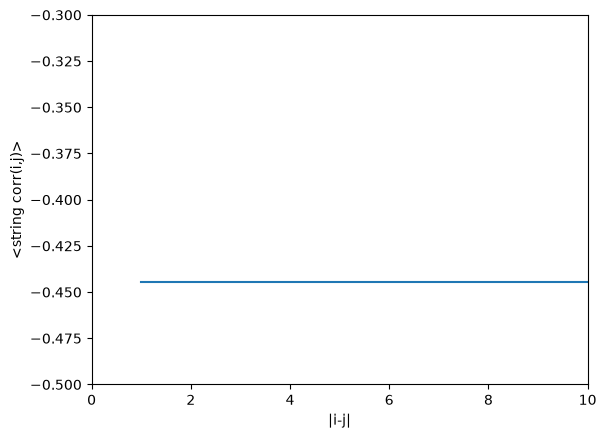

In [ ]:
# optional exercise: hidden order in the string operator
exp_sz = np.diag(np.exp(1j * np.pi * sz_sprs.diagonal()))
Eexpz_mat =  cqd.operators.build_E_mat_MPS(a_tensor_arr, exp_sz).real

# due to translation invariance we can fix i=0
# show the power of the MPS: large system
N = 100
    
# same for mps
string_corr_list = np.zeros((N - 1,))
for i in range(N-1):
    idx_arr = np.arange(i + 2)
    op_arr = np.array([Ez_mat if (idx == 0 or idx == i + 1) else Eexpz_mat for idx in idx_arr])
    string_corr_list[i] =  cqd.operators.corr_func_MPS(N, E_mat, idx_arr, op_arr)
    
rvec = np.arange(1, N)
plt.plot(rvec, string_corr_list)
plt.xlabel("|i-j|")
plt.ylabel("<string corr(i,j)>")
plt.xlim(0, 10)
plt.ylim(-0.5, -0.3)
plt.show()

# -> is indeed constant and non-zero!